# Goal

Write the code from scratch to do the Module 2 homework from cohort of 2025

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')

In [3]:
columns_to_use = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg']

In [4]:
df = df[columns_to_use]

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

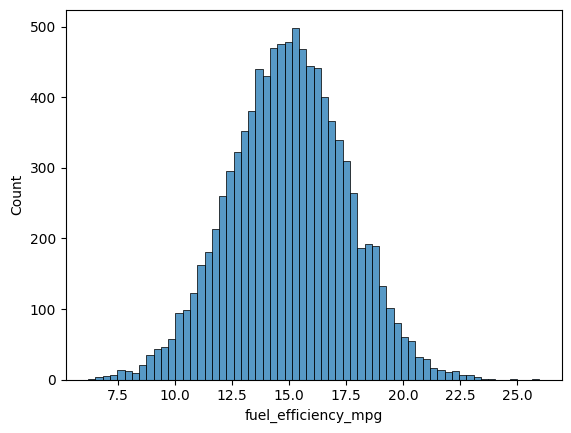

In [7]:
sns.histplot(df['fuel_efficiency_mpg'])
# The histogram of the values to be predicted look very much like a gaussian distribution

In [8]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight         float64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [16]:
df.isna().sum() > 0
# horesepower has some nan values

engine_displacement    False
horsepower              True
vehicle_weight         False
model_year             False
fuel_efficiency_mpg    False
dtype: bool

In [17]:
df['horsepower'].median()

np.float64(149.0)

In [104]:
def split_train_val_test(df, seed):

    df = df.copy()

    nr_of_rows = len(df)
    train_len = 0.6
    val_len = 0.2
    test_len = 0.2

    all_idx = np.arange(nr_of_rows)
    np.random.seed(seed)
    np.random.shuffle(all_idx)
    train_idxs = all_idx[0:int(train_len*nr_of_rows)]
    val_idxs = all_idx[int(train_len*nr_of_rows):int(train_len*nr_of_rows)+int(val_len*nr_of_rows)]
    test_idxs = all_idx[int(train_len*nr_of_rows)+int(val_len*nr_of_rows):]

    df_train = df.iloc[train_idxs,:]
    df_val = df.iloc[val_idxs,:]
    df_test = df.iloc[test_idxs,:]

    y_train = df_train['fuel_efficiency_mpg']
    del df_train['fuel_efficiency_mpg']

    y_val = df_val['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']

    y_test = df_test['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    return df_train, df_val, df_test, y_train, y_val, y_test



In [105]:
def prepare_X(df, fill_value=0):

    df = df.copy()


    idxs = (df['horsepower'].isnull() == True).index
    df.loc[idxs,'horsepower'] = fill_value

    X = df.to_numpy()
    x_0 = np.ones((X.shape[0],1))

    X = np.concat([x_0,X],axis=1)

    return X


    

In [106]:
def RMSE(y_hat, y):
    assert y_hat.shape == y.shape
    error = y_hat - y
    se = error ** 2
    mse = se.mean()
    rmse = np.sqrt(mse)
    return rmse


In [107]:
def linear_regression(X, y, r=0):
    gram_mat = X.T.dot(X)
    gram_mat_reg = gram_mat + r*np.eye(*gram_mat.shape)
    inv_gram_mat = np.linalg.inv(gram_mat_reg)
    w = inv_gram_mat @ X.T @ y
    return w


In [100]:
median = df_train['horsepower'].median()
#median=0
X_train = prepare_X(df_train, fill_value=median)
w_total = linear_regression(X_train, y_train, r=0.001)
X_val = prepare_X(df_val, fill_value=median)

y_hat_val = X_val.dot(w_total)
print(RMSE(y_hat_val, y_val).round(2))

0.55


In [108]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:

    X_train = prepare_X(df_train, fill_value=median)
    w_total = linear_regression(X_train, y_train, r=r)
    X_val = prepare_X(df_val, fill_value=median)

    y_hat_val = X_val.dot(w_total)
    print("r",r, "RMSE",RMSE(y_hat_val, y_val).round(5))

r 0 RMSE 75.48368
r 0.01 RMSE 0.55136
r 0.1 RMSE 0.55136
r 1 RMSE 0.55136
r 5 RMSE 0.55135
r 10 RMSE 0.55134
r 100 RMSE 0.55123


In [116]:
rmse_list = []
r = 0
for s in range(0,10):
    median = 0.0001
    df_train, df_val, df_test, y_train, y_val, y_test = split_train_val_test(df, seed=s)
    X_train = prepare_X(df_train, fill_value=median)
    w_total = linear_regression(X_train, y_train, r=r)
    X_val = prepare_X(df_val, fill_value=median)

    y_hat_val = X_val.dot(w_total)
    rmse = RMSE(y_hat_val, y_val)
    print("s",s, "RMSE",rmse.round(5))
    rmse_list.append(rmse)


s 0 RMSE 0.55856
s 1 RMSE 0.57404
s 2 RMSE 0.62315
s 3 RMSE 0.5546
s 4 RMSE 0.55683
s 5 RMSE 0.57429
s 6 RMSE 0.565
s 7 RMSE 0.5836
s 8 RMSE 0.57947
s 9 RMSE 0.5924


In [117]:
round(np.std(rmse_list),3)

np.float64(0.02)

In [121]:
df_train, df_val, df_test, y_train, y_val, y_test = split_train_val_test(df, seed=9)
df_full_train = pd.concat([df_train, df_val])
y_full_train = np.concat([y_train, y_val], axis=0)


In [124]:
X_full_train = prepare_X(df_full_train, fill_value=0)
w_total = linear_regression(X_full_train, y_full_train, r=0.001)
X_test = prepare_X(df_test, fill_value=0)

y_hat_test = X_test.dot(w_total)
rmse = RMSE(y_hat_test, y_test)
print(rmse)

0.5471903718300173


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

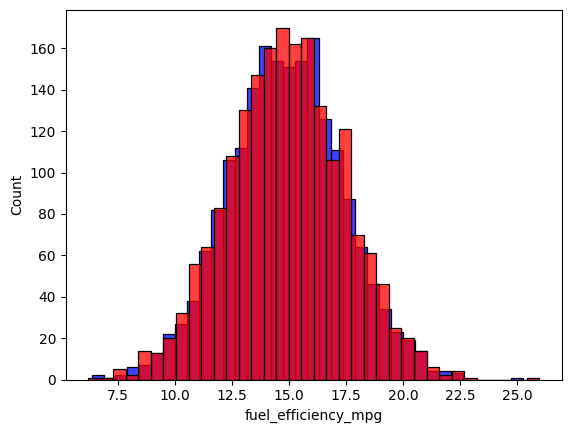

In [125]:
sns.histplot(y_hat_test, color='blue')
sns.histplot(y_test, color='red')